In [16]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
import torchvision.transforms as transforms
from torch.utils import data
import matplotlib.pyplot as plt
import numpy as np
import random

# 设置种子

In [17]:
def set_seed(seed=42):
    random.seed(seed)          # Python 内置 random
    np.random.seed(seed)       # NumPy
    torch.manual_seed(seed)    # PyTorch CPU
    torch.cuda.manual_seed(seed)        # 当前 GPU
    torch.cuda.manual_seed_all(seed)     # 所有 GPU（如果有多卡）
    torch.backends.cudnn.deterministic = True   # 让 cuDNN 采用确定性算法
    torch.backends.cudnn.benchmark = False      # 关闭自动寻找最优卷积算法（保证可复现，但可能降低性能）

# 在代码开头调用
set_seed(42)

# 模型架构——ResNet-18

#### 累加器 方便计算准确率

In [18]:
class Accumulator:
    def __init__(self, n):
        self.data = [0.0] * n
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
    def reset(self):
        self.data = [0.0] * len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

#### 残差块

基本结构是：卷积层1 -> 标准规范化层1 -> 激活函数 -> 卷积层2 -> 标准规范化层2

标准规范化层2的输出再加上X就是最终输出。

其中使用到use_1x1conv是用于将X的形状和BN2层形状统一而设计的。

In [19]:
class Residual(nn.Module):
    def __init__(self, input_channels, num_channels, use_1x1conv = False, strides = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels, kernel_size = 3, padding = 1, stride = strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels, kernel_size = 3, padding = 1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels, kernel_size = 1, stride = strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

ResNet-18的第一块

In [20]:
b1 = nn.Sequential(nn.Conv2d(3, 64, kernel_size = 7, stride = 2, padding = 3),
                 nn.BatchNorm2d(64), nn.ReLU(),
                 nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1))

因为接下来有4个残差块，所以使用resnet_block：

每个残差块有两个卷积层，这两个卷积层的输出通道数相同。

第一个残差块的两个卷积层都是num_channels -> num_channels，

后面三个残差块的第一个卷积层是input_channels -> num_channels，并且使用X上的1x1卷积核调整形状

In [21]:
def resnet_block(input_channels, num_channels, num_residuals, 
                 first_block = False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels, 
                                use_1x1conv = True, strides = 2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk
        

In [22]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block = True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

把所有块拼在一起，最后加入平均池化层、暂退层、以及全连接层。

实验了暂退层的参数为0.3，0.4，0.5, 其中0.3的效果最好。

另外需要注意的是，在教材里全连接层的输出通道是10，这里是2， 因为是二分类问题。

In [23]:
net = nn.Sequential(b1, b2, b3, b4, b5,
                   nn.AdaptiveAvgPool2d((1, 1)),
                   nn.Flatten(), nn.Dropout(0.3), nn.Linear(512, 2))

# 图像增广

仅对训练集使用图像增广，验证集不使用。

同时两个数据集都使用数据归一化，加速收敛、稳定梯度。

In [24]:
train_augs = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
test_augs = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

# 加载数据

In [25]:
#定义一个包装类，为每个子集单独应用变换
class TransformSubset(data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

In [26]:
def load_data(batch_size, resize=None, train_augs=None, test_augs=None):
    train_dir = '/kaggle/input/datasets/tongpython/cat-and-dog/training_set/training_set'
    
    # 1. 先加载原始数据集（不应用任何变换）
    full_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=None)
    
    # 2. 划分训练集和验证集（基于索引）
    val_size = int(len(full_dataset) * 0.3)
    train_size = len(full_dataset) - val_size
    train_subset, val_subset = data.random_split(full_dataset, [train_size, val_size])
    
    # 3. 分别包装训练集和验证集，应用不同的变换
    train_dataset = TransformSubset(train_subset, train_augs)
    val_dataset = TransformSubset(val_subset, test_augs)
    
    # 4. 创建 DataLoader
    train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader

# 训练函数

In [27]:
#返回正确数
def accuracy(y_hat, y):
    if y_hat.ndim > 1:
        y_hat = y_hat.argmax(dim=1)
    return (y_hat == y).sum().item()

def evaluate_accuracy_gpu(net, data_iter, device = None):
    if isinstance(net, nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                X =[x.to(device) for x in X]
            else:
                X = X.to(device)

            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [28]:
def train(net, train_iter, test_iter, num_epochs, lr, device):
    #使用xavier权重初始化
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    #使用SGD优化器momentum = 0.9, 权重衰减为1e-4
    optimizer = torch.optim.SGD(net.parameters(), lr = lr, momentum=0.9, weight_decay=1e-4)
    #损失函数采用交叉熵，因为是分类模型
    loss = nn.CrossEntropyLoss()
    #把算出来的准确率和损失存起来方便后面一起画图
    train_losses, train_accs, test_accs = [], [], []
    #用于确定最好的模型
    best_acc = 0

    for epoch in range(num_epochs):
        metric= Accumulator(3)
        for i,(x, y) in enumerate(train_iter):
            optimizer.zero_grad()
            x, y = x.to(device), y.to(device)
            y_hat = net(x)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * x.shape[0], accuracy(y_hat, y), x.shape[0])
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            
            
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(net.state_dict(), 'best_cat_dog_model.pth')
        print(f'Epoch {epoch+1}: loss={train_l:.4f}, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}')
        train_losses.append(train_l)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
    return train_losses, train_accs, test_accs

# 运行

## 设置超参数

In [29]:
lr, num_epochs, batch_size = 0.001, 50, 64
train_iter, test_iter = load_data(batch_size, resize = 224, train_augs=train_augs, test_augs=test_augs)

## 开始训练 

In [30]:
train_losses, train_accs, test_accs = [], [], []
train_losses, train_accs, test_accs = train(net, train_iter, test_iter, num_epochs, lr, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

training on cuda
Epoch 1: loss=0.7774, train_acc=0.5751, test_acc=0.6018
Epoch 2: loss=0.7069, train_acc=0.5721, test_acc=0.5839
Epoch 3: loss=0.6641, train_acc=0.5835, test_acc=0.6360
Epoch 4: loss=0.6266, train_acc=0.6415, test_acc=0.6114
Epoch 5: loss=0.5910, train_acc=0.6834, test_acc=0.6547
Epoch 6: loss=0.5792, train_acc=0.6904, test_acc=0.6110
Epoch 7: loss=0.5619, train_acc=0.7007, test_acc=0.7218
Epoch 8: loss=0.5599, train_acc=0.7118, test_acc=0.7268
Epoch 9: loss=0.5303, train_acc=0.7295, test_acc=0.7097
Epoch 10: loss=0.5102, train_acc=0.7421, test_acc=0.7259
Epoch 11: loss=0.5043, train_acc=0.7539, test_acc=0.7280
Epoch 12: loss=0.4884, train_acc=0.7634, test_acc=0.7264
Epoch 13: loss=0.4733, train_acc=0.7744, test_acc=0.7622
Epoch 14: loss=0.4602, train_acc=0.7809, test_acc=0.7659
Epoch 15: loss=0.4307, train_acc=0.7953, test_acc=0.7451
Epoch 16: loss=0.4337, train_acc=0.7921, test_acc=0.7734
Epoch 17: loss=0.4134, train_acc=0.8064, test_acc=0.7601
Epoch 18: loss=0.4002, 

# 作图

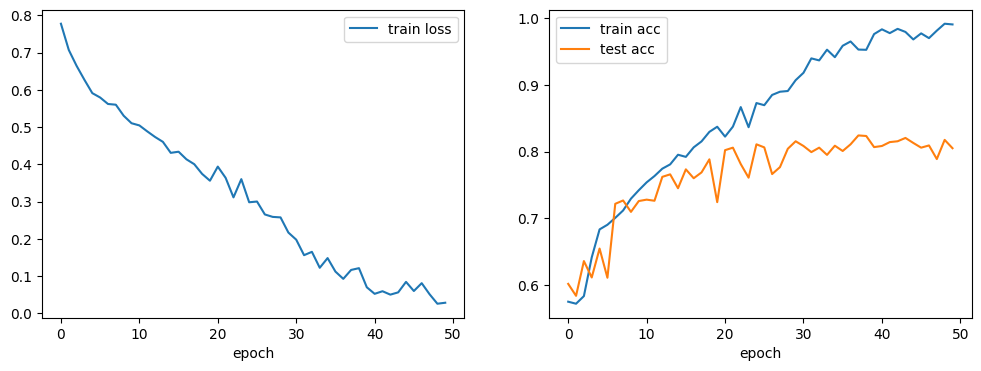

In [31]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='train loss')
plt.xlabel('epoch')
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_accs, label='train acc')
plt.plot(test_accs, label='test acc')
plt.xlabel('epoch')
plt.legend()
plt.show()